# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Jihan Camilla Az Zahra
- **Email:** jihancamilla10@gmail.com / m002b4kx2068@bangkit.academy
- **ID Dicoding:** jihancamilla

## Menentukan Pertanyaan Bisnis

- Bagaimana performa penyewaan sepeda dalam 2 tahun terakhir terakhir?
- Bagaimana Temperatur dan kelembaban berkorelasi dengan penyewaan sepeda?
- Pada musim apa pelanggan paling banyak menyewa sepeda?
- Pada jam berapa pelanggan paling banyak menyewa sepeda?

## Import Semua Packages/Library yang Digunakan

In [26]:
# Memanggil semua packages / library yang akan digunakan
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [27]:
# Memuat tabel data pada file day.csv
day_df = pd.read_csv("day.csv")
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [28]:
# Memuat tabel data pada file hour.csv
hour_df = pd.read_csv("hour.csv")
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:**
- Kode diatas menampilkan 5 baris pertama dari DataFrame day_df dan hour_df

### Assessing Data

In [29]:
# memeriksa tipe data dari tiap kolom dalam day_df.
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [30]:
# memeriksa tipe data dari tiap kolom dalam hour_df.
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


**Insight:**
- Jika kita perhatikan, tidak ada masalah dengan tipe data dari seluruh kolom tersebut, baik di day_df ataupun hour_df. Hanya saja pada kedua data type dteday berbentuk object. Kami akan mengganti data type ini menjadi date time pada proses clearing. Kami juga akan mengecek missing values nya.

In [31]:
# mengecek apakah ada missing value di day_df
day_df.isna().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0


In [32]:
# mengecek apakah ada missing value di hour_df
hour_df.isna().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0


**Insight:**
- Terbukti bahwa tidak ada data yang missing value di day_df dan di hour_df. Selanjutkan kita akan mengecek apakah ada data yang terduplikat.

In [33]:
# mengecek apakah ada duplikasi di day_df
print("Jumlah duplikasi: ", day_df.duplicated().sum())

Jumlah duplikasi:  0


In [34]:
# mengecek apakah ada duplikasi di hour_df
print("Jumlah duplikasi: ", hour_df.duplicated().sum())

Jumlah duplikasi:  0


**Insight:**
- Ternyata tidak ada data yang terduplikat pada day_df dan hour_df. Selanjutnya kami akan memeriksa parameter statistik dari kolom numerik yang terdapat dalam day_df dan hour_df.

In [35]:
# mengecek parameter statistik dari kolom numerik dalam day_df
day_df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [36]:
# memeriksa parameter statistik dari kolom numerik dalam hour_df
hour_df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


**Insight:**
- Kode di atas menampilkan ringkasan parameter statistik. Jika diperhatikan, tidak ada keanehan pada hasil tersebut (cukup akurat) baik pada day_df ataupun hour_df. Hanya saja semua data pada season, mnth,  yr, holiday, weekday, workingday, weathersit, hum, dan windspeed bernilai integer / float sehingga ini akan menyulitkan mengolah data.

### Cleaning Data

**To Do:**
- Akan menghapus kolom yang tidak akan digunakan pada analisis data ini, seperti atemp (karena kami akan mengolah dari data temp saja), weathersit, holiday, weekday, workingday windspeed, dan casual
- Akan mengubah data integer / float menjadi string sesuai dengan inputnya pada season, mnth, dan yr.

In [37]:
# akan mengganti tipe data dteday dari object menjadi datetime
day_df['dteday'] = pd.to_datetime(day_df['dteday'])
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

In [38]:
# akan menghapus kolom holiday, weekday, workingday, weathersit, atemp, windspeed, dan casual karena tidak akan kita olah datanya
day_df.drop(['holiday'], axis = 1, inplace= True)
day_df.drop(['weekday'], axis = 1, inplace= True)
day_df.drop(['workingday'], axis = 1, inplace= True)
day_df.drop(['weathersit'], axis = 1, inplace= True)
day_df.drop(['atemp'], axis = 1, inplace= True)
day_df.drop(['windspeed'], axis = 1, inplace= True)
day_df.drop(['casual'], axis = 1, inplace= True)
hour_df.drop(['holiday'], axis = 1, inplace= True)
hour_df.drop(['weekday'], axis = 1, inplace= True)
hour_df.drop(['workingday'], axis = 1, inplace= True)
hour_df.drop(['weathersit'], axis = 1, inplace= True)
hour_df.drop(['atemp'], axis = 1, inplace= True)
hour_df.drop(['windspeed'], axis = 1, inplace= True)
hour_df.drop(['casual'], axis = 1, inplace= True)

In [39]:
# akan mengubah input data season, month, dan year dari integer / float menjadi string / kategori
columns = ['season', 'mnth', 'yr']

for column in columns:
    day_df[column] =  day_df[column].astype("category")
    hour_df[column] =  hour_df[column].astype("category")

In [40]:
# mengganti isi kolom dengan input aslinya

# mengganti data season menjadi: 1:Spring, 2:Summer, 3:Fall, 4:Winter
day_df.season.replace((1,2,3,4), ('Spring','Summer','Fall','Winter'), inplace=True)
hour_df.season.replace((1,2,3,4), ('Spring','Summer','Fall','Winter'), inplace=True)

# mengganti data month menjadi: 1:Jan, 2:Feb, 3:Mar, 4:Apr, 5:May, 6:Jun, 7:Jul, 8:Aug, 9:Sep, 10:Oct, 11:Nov, 12:Dec
day_df.mnth.replace((1,2,3,4,5,6,7,8,9,10,11,12),('Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'), inplace=True)
hour_df.mnth.replace((1,2,3,4,5,6,7,8,9,10,11,12),('Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'), inplace=True)

# mengganti data yr menjadi: 0:2011, 1:2012
day_df.season.replace((0,1), ('2011','2012'), inplace=True)
hour_df.season.replace((0,1), ('2011','2012'), inplace=True)

<ipython-input-40-661d458998e1>:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  day_df.season.replace((1,2,3,4), ('Spring','Summer','Fall','Winter'), inplace=True)
<ipython-input-40-661d458998e1>:4: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  day_df.season.replace((1,2,3,4), ('Spring','Summer','Fall','Winter'), i

**Insight:**
- Kita sudah menghapus kolom kolom yang tidak akan kita perlukan untuk analsis pada kali ini. Mungkin ini akan menyebabkan banyaknya kehilangan informasi tetapi di lain sisi ini juga akan memudahkan kita untuk mengolah data karena kita akan fokus pada kolom kolom yang akan digunakan saja.
- Kita juga sudah mengganti kolom kolom integer / float dan mengubahnya ke string sebagaimana input aslinya.
- Selanjutnya data final ini akan diolah ke step berikutnya.

## Exploratory Data Analysis (EDA)

### Explore Data day_df

In [41]:
# menampilkan rangkuman parameter statistik pada data hour_df
day_df.describe(include="all")

,instant,dteday,season,yr,mnth,temp,hum,registered,cnt
count,731.000000,731,731,731.0,731,731.000000,731.000000,731.000000,731.000000
unique,NaN,NaN,4,2.0,12,NaN,NaN,NaN,NaN
top,NaN,NaN,Fall,1.0,Jan,NaN,NaN,NaN,NaN
freq,NaN,NaN,188,366.0,62,NaN,NaN,NaN,NaN
mean,366.000000,2012-01-01 00:00:00,NaN,NaN,NaN,0.495385,0.627894,3656.172367,4504.348837
min,1.000000,2011-01-01 00:00:00,NaN,NaN,NaN,0.059130,0.000000,20.000000,22.000000
25%,183.500000,2011-07-02 12:00:00,NaN,NaN,NaN,0.337083,0.520000,2497.000000,3152.000000
50%,366.000000,2012-01-01 00:00:00,NaN,NaN,NaN,0.498333,0.626667,3662.000000,4548.000000
75%,548.500000,2012-07-01 12:00:00,NaN,NaN,NaN,0.655417,0.730209,4776.500000,5956.000000
max,731.000000,2012-12-31 00:00:00,NaN,NaN,NaN,0.861667,0.972500,6946.000000,8714.000000


**Insight:**

Berdasarkan rangkuman parameter statistik dari data day_df, diperoleh:

- Dari 17379 banyaknya data pada day_df, terlihat bahwa rata-rata temperatur ada pada skala 0.49, kelembapan pada skala 0.62, dan rata-rata penyewaan sepeda pada angka 4504
- Terlihat bahwa angka penyewaan sepeda terbesar terjadi hingga 8714 dan penyewaan sepeda terkecil terjadi hingga 22

In [42]:
# menampilkan jumlah penyewaan sepeda tiap season
day_df.groupby(by="season").cnt.sum().sort_values(ascending=False).reset_index().head(10)

<ipython-input-42-ced057343cd0>:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  day_df.groupby(by="season").cnt.sum().sort_values(ascending=False).reset_index().head(10)


,season,cnt
0,Fall,1061129
1,Summer,918589
2,Winter,841613
3,Spring,471348


**Insight:**
- Terlihat bahwa penyewaan sepeda sering terjadi pada musim gugur, yaitu hingga total mencapai 1061129 sepeda.
- Musim kedua yang paling sering terjadi penyewaan adalah musim panas, yaitu hingga 918589 sepeda.
- Setelah itu yang paling sering terjadi penyewaan adalah musim dingin, yaitu sebesar 841613. Dilanjut dengan musim yang paling jarang terjadinya penyewaan sepeda adalah musim semi, yaitu sebesar 471348 sepeda.

### Explore Data hour_df

In [43]:
# menampilkan rangkuman parameter statistik pada data hour_df
hour_df.describe(include="all")

,instant,dteday,season,yr,mnth,hr,temp,hum,registered,cnt
count,17379.0000,17379,17379,17379.0,17379,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
unique,NaN,NaN,4,2.0,12,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Fall,1.0,May,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,4496,8734.0,1488,NaN,NaN,NaN,NaN,NaN
mean,8690.0000,2012-01-02 04:08:34.552045568,NaN,NaN,NaN,11.546752,0.496987,0.627229,153.786869,189.463088
min,1.0000,2011-01-01 00:00:00,NaN,NaN,NaN,0.000000,0.020000,0.000000,0.000000,1.000000
25%,4345.5000,2011-07-04 00:00:00,NaN,NaN,NaN,6.000000,0.340000,0.480000,34.000000,40.000000
50%,8690.0000,2012-01-02 00:00:00,NaN,NaN,NaN,12.000000,0.500000,0.630000,115.000000,142.000000
75%,13034.5000,2012-07-02 00:00:00,NaN,NaN,NaN,18.000000,0.660000,0.780000,220.000000,281.000000
max,17379.0000,2012-12-31 00:00:00,NaN,NaN,NaN,23.000000,1.000000,1.000000,886.000000,977.000000


**Insight:**

Berdasarkan rangkuman parameter statistik dari data hour_df, diperoleh:

- Dari 17379 banyaknya data pada day_df, terlihat bahwa rata-rata penyewaan sepeda terjadi di jam 11:54, maksimum jam penyewaan sepeda terjadi pada jam 23:00, dan minimum jam penyewaan sepeda terjadi pada jam 00:00

In [44]:
# menampilkan penyewaan sepeda berdasarkan jam
hour_df.groupby(by="hr").agg({
    "cnt": ["sum"]
})

,cnt
,sum
hr,
0,39130
1,24164
2,16352
3,8174
4,4428
5,14261
6,55132
7,154171


**Insight:**
- Terlihat bahwa penyewaan sepeda sering terjadi di jam 17:00, yaitu sebanyak 336860. Kemudian dilanjut di jam 18:00, yaitu sebanyak 309772.
- Sedangkan penyewaan sepeda yang jarang terjadi ada di jam 04:00, yaitu sebanyak 4428.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana performa penyewaan sepeda dalam 2 tahun terakhir?

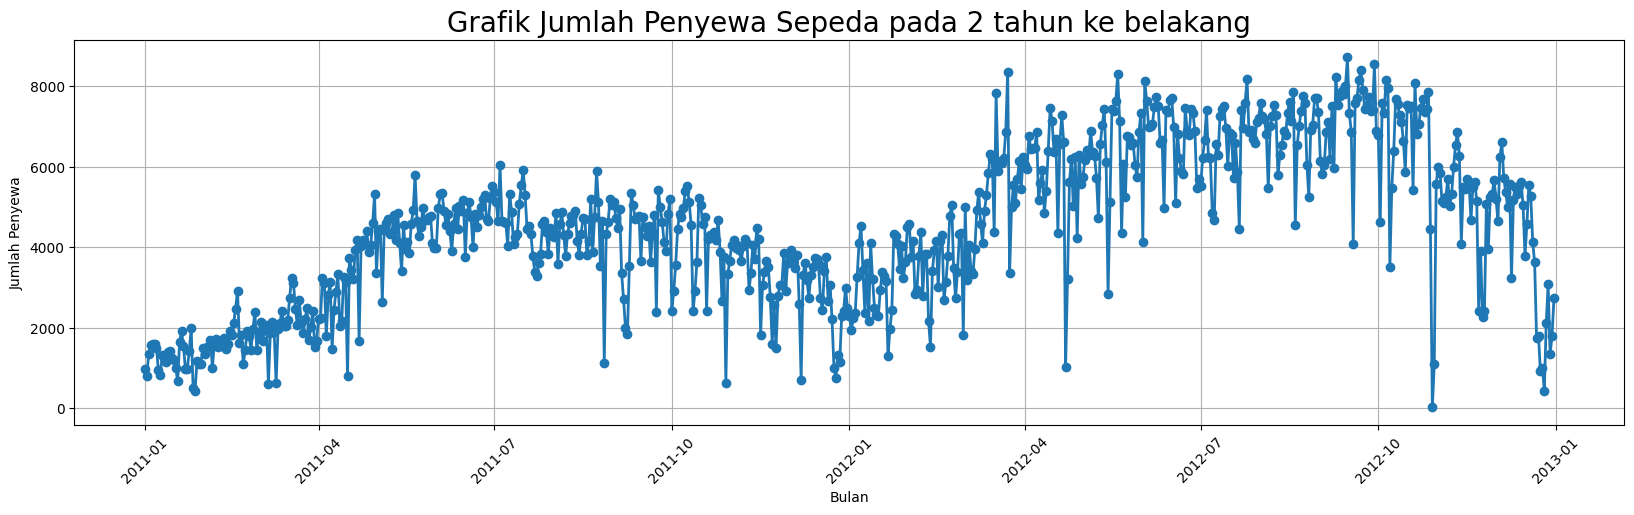

In [45]:
# membuat figure dengan ukuran (20,5)
plt.figure(figsize=(20, 5))

# menampilkan grafik dengan sumbu x adalah cnt dan sumbu y adalah dteday
plt.plot(day_df["dteday"], day_df[["cnt"]], marker="o", linewidth=2)

# membuat judul plot
plt.title("Grafik Jumlah Penyewa Sepeda pada 2 tahun ke belakang", loc="center", fontsize=20)

# penamaan untuk sumbu x
plt.xlabel('Bulan')

# penamaan untuk sumbu y
plt.ylabel('Jumlah Penyewa')

# mengatur font pada sumbu x
plt.xticks(fontsize=10)

# mengatur font pada sumbu y
plt.yticks(fontsize=10)

# merotasi text pada sumbu x
plt.xticks(rotation=45)

# membuat grid untuk memudahkan membaca plot
plt.grid()

# menampilkan plot
plt.show()

<ipython-input-46-53e438dfed85>:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  grouped_data = day_df.groupby(pd.Grouper(key='dteday', freq='M'))['cnt'].sum().reset_index()


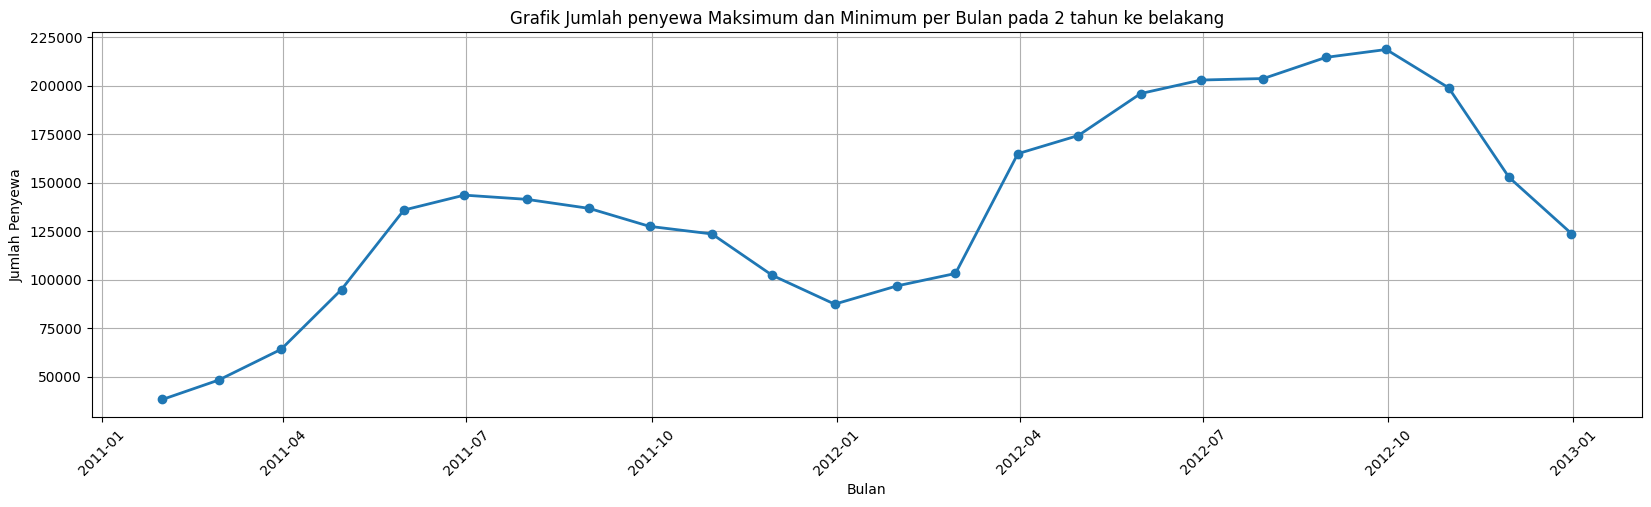

In [46]:
# mengelompokkan berdasarkan bulan dan tahun, dan menjumlahkan kolom 'cnt'
# hal ini dilakukan untuk mengetahui jumlah penyewa sepeda per bulannya
grouped_data = day_df.groupby(pd.Grouper(key='dteday', freq='M'))['cnt'].sum().reset_index()

# membuat figure dengan ukuran (20,5)
plt.figure(figsize=(20, 5))

# menampilkan grafik dengan sumbu x adalah cnt dan sumbu y adalah dteday
plt.plot(grouped_data['dteday'], grouped_data['cnt'], marker='o', linewidth=2)

# membuat judul plot
plt.title('Grafik Jumlah penyewa Maksimum dan Minimum per Bulan pada 2 tahun ke belakang')

# penamaan untuk sumbu x
plt.xlabel('Bulan')

# penamaan untuk sumbu y
plt.ylabel('Jumlah Penyewa')

# merotasi text pada sumbu x
plt.xticks(rotation=45)

# membuat grid untuk memudahkan membaca plot
plt.grid()

# menampilkan plot
plt.show()

**Insight:**

Berdasarkan visualisasi di atas, terlihat bahwa penyewaan sepeda selama 2 tahun ke belakang berfluktuasi.

Jika kita tinjau pada grafik jumlah penyewa per data yang ada, maka kita dapatkan bulan september tahun 2012 terjadi penyewaan maksimum. Sedangkan pada bulan november tahun 2012 terjadi penjualan minimum.

Jika kita tinjau berdasarkan total penyewa per bulannya, didapat bulan oktober tahun 2012 yang merupakan bulan dengan total penyewa terbesar ada pada bulan januari tahun 2011 terjadi total penyewaan terkecil.

### Pertanyaan 2: Bagaimana Temperatur dan Kelembaban Berkorelasi Dengan Penyewaan Sepeda?

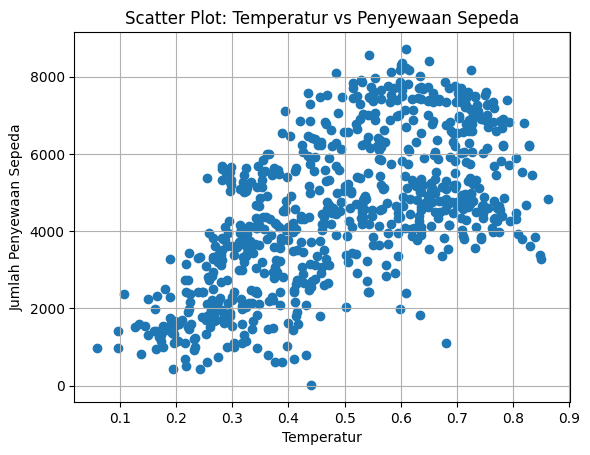

Korelasi antara temperatur dan jumlah penyewaan sepeda: 0.63
Kovarians antara temperatur dan jumlah penyewaan sepeda: 222.51


In [47]:
# memplot data sebagai scatter plot
plt.scatter(x=day_df['temp'], y=day_df['cnt'])

# membuat judul plot
plt.title('Scatter Plot: Temperatur vs Penyewaan Sepeda')

# penamaan untuk sumbu x
plt.xlabel('Temperatur')

# penamaan untuk sumbu x
plt.ylabel('Jumlah Penyewaan Sepeda')

# memunculkan grid
plt.grid()

# memunculkan plot
plt.show()

# Menghitung korelasi
correlation = day_df['temp'].corr(day_df['cnt'])
print(f"Korelasi antara temperatur dan jumlah penyewaan sepeda: {correlation:.2f}")

# Menghitung kovariansinya
covariance = day_df['temp'].cov(day_df['cnt'])
print(f"Kovarians antara temperatur dan jumlah penyewaan sepeda: {covariance:.2f}")

**Insight:**

Berdasarkan visualisasi di atas, terlihat bahwa korelasi yang dihasilkan adalah 0.63 dimana lebih dekat ke 1. Hal ini menunjukkan korelasi yang bersesuaian antara temperatur dan jumlah penyewaan sepeda.

Berdasarkan kovariansi yang dihasilkan, yaitu 222.51 yang merupakan positive artinya menunjukkan korelasi yang positif / bersesuaian antara temperatur dan jumlah penyewaan sepeda.

Jadi, temperatur mempunya korelasi yang bersesuaian dengan penyewaan sepeda.

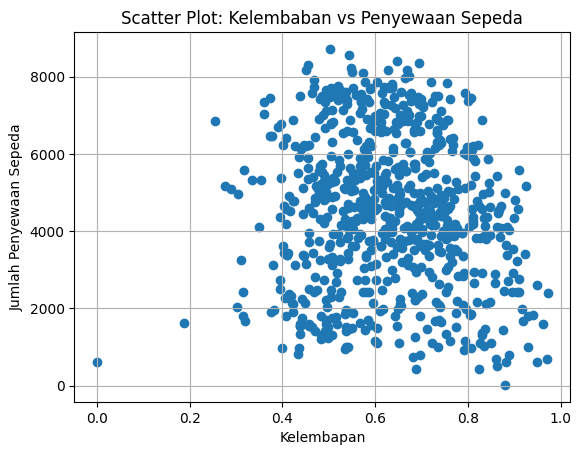

Korelasi antara kelembaban dan jumlah penyewaan sepeda: -0.10
Kovarians antara kelembaban dan jumlah penyewaan sepeda: -27.77


In [48]:
# memplot data sebagai scatter plot
plt.scatter(x=day_df['hum'], y=day_df['cnt'])

# membuat judul plot
plt.title('Scatter Plot: Kelembaban vs Penyewaan Sepeda')

# penamaan untuk sumbu x
plt.xlabel('Kelembapan')

# penamaan untuk sumbu x
plt.ylabel('Jumlah Penyewaan Sepeda')

# memunculkan grid
plt.grid()

# memunculkan plot
plt.show()

# Menghitung korelasi
correlation = day_df['hum'].corr(day_df['cnt'])
print(f"Korelasi antara kelembaban dan jumlah penyewaan sepeda: {correlation:.2f}")

# Menghitung kovariansinya
covariance = day_df['hum'].cov(day_df['cnt'])
print(f"Kovarians antara kelembaban dan jumlah penyewaan sepeda: {covariance:.2f}")

**Insight:**

Berdasarkan visualisasi di atas, terlihat bahwa korelasi yang dihasilkan adalah -0.10. Hal ini menunjukkan korelasi yang berlawanan antara kelembaban dan jumlah penyewaan sepeda, karena korelasi yang dihasilkan negatif.

Berdasarkan kovariansi yang dihasilkan, yaitu -27.77 yang merupakan negatif artinya menunjukkan korelasi yang negatif / berlawanan antara kelembaban dan jumlah penyewaan sepeda.

Jadi, kelembaban mempunya korelasi yang berlawanan dengan penyewaan sepeda.

### Pertanyaan 3: Pada musim apa pelanggan paling banyak menyewa sepeda?

<ipython-input-49-4968561cf5a6>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/usr/local/lib/python3.10/dist-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.10/dist-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.10/dist-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tupl

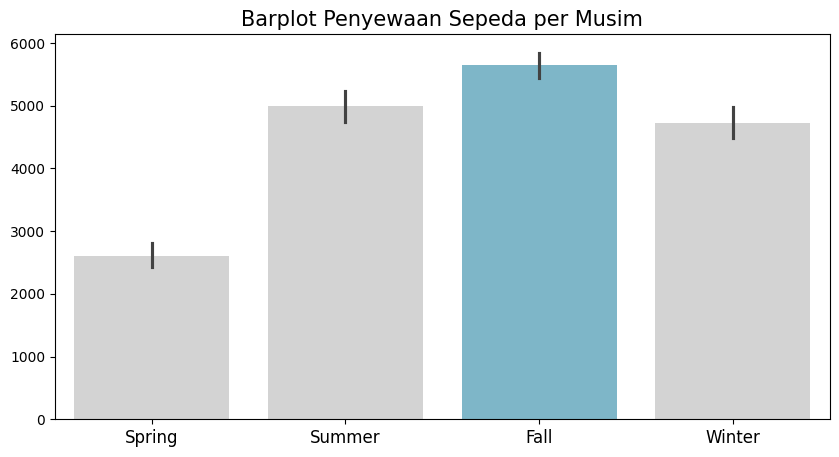

In [49]:
# membuat beberapa warna untuk barplot
colors = ["#D3D3D3", "#D3D3D3", "#72BCD4", "#D3D3D3"]

# membuat figure dengan ukuran (10,5)
plt.figure(figsize=(10, 5))

# membuat barplot penyewaan sepeda setiap musimnya
sns.barplot(
    y="cnt",
    x="season",
    data = day_df.sort_values(by="season", ascending=False),
    palette=colors
)

# membuat judul plot
plt.title("Barplot Penyewaan Sepeda per Musim", loc="center", fontsize=15)

# penamaan untuk sumbu x
plt.ylabel(None)

# penamaan untuk sumbu y
plt.xlabel(None)

# mengatur font dari sumbu x
plt.tick_params(axis='x', labelsize=12)

# menampilkan plot
plt.show()

**Insight:**

Berdasarkan visualisasi barplot di atas, terlihat bahwa musim yang mempunya paling banyak penyewaan sepeda adalah musim gugur, yaitu sebesar 1061129 sepeda.

### Pertanyaan 4: Pada jam berapa pelanggan paling banyak menyewa sepeda?

In [50]:
# melakukan grouping hr dan cnt (jam dan jumlah penyewaan sepeda)
sum_order_items_df = hour_df.groupby("hr").cnt.sum().sort_values(ascending=False).reset_index()

# menampilkan groupingnya
sum_order_items_df.head(15)

,hr,cnt
0,17,336860
1,18,309772
2,8,261001
3,16,227748
4,19,226789
5,13,184919
6,12,184414
7,15,183149
8,14,175652
9,20,164550


<ipython-input-51-e7aefccb6ed7>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="hr", y="cnt", data=sum_order_items_df.head(5), palette=colors1, ax=ax[0])
/usr/local/lib/python3.10/dist-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.10/dist-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.10/dist-packages/seaborn/_base.py:949: FutureWarning: Wh

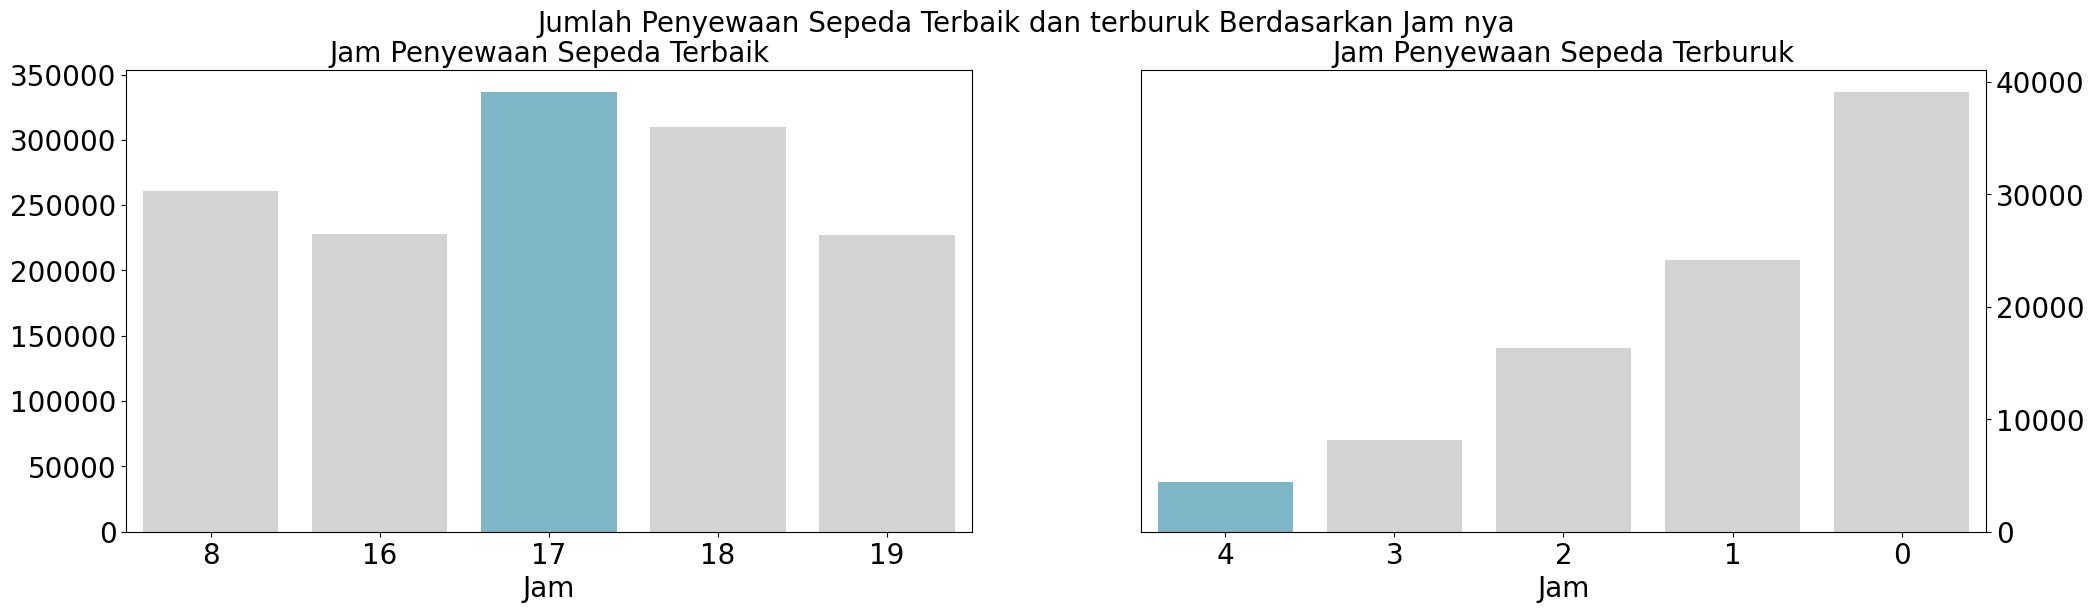

In [51]:
# membuat bar chart terlebih dahulu untuk melihat perbedaan jumlah penyewaan sepeda
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(24, 6))

# memberi warna pada barplot
colors1 = ["#D3D3D3", "#D3D3D3", "#72BCD4", "#D3D3D3", "#D3D3D3"]
colors2 = ["#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3", "#72BCD4"]

# membuat barplot untuk jumlah penyewa sepeda terbaik
sns.barplot(x="hr", y="cnt", data=sum_order_items_df.head(5), palette=colors1, ax=ax[0])

# mengatur judul, label, warna, dan font size untuk barplot pertama (jumlah penyewaan sepeda terbaik)
ax[0].set_ylabel(None)
ax[0].set_xlabel("Jam", fontsize=20)
ax[0].set_title("Jam Penyewaan Sepeda Terbaik", loc="center", fontsize=20)
ax[0].tick_params(axis ='y', labelsize=20)
ax[0].tick_params(axis ='x', labelsize=20)

# membuat barplot untuk jumlah penyewa sepeda terburuk
sns.barplot(x="hr", y="cnt", data=sum_order_items_df.sort_values(by="hr", ascending=True).head(5), palette=colors2, ax=ax[1])

# mengatur judul, label, warna, dan font size untuk barplot kedua (jumlah penyewaan sepeda terburuk)
ax[1].set_ylabel(None)
ax[1].set_xlabel("Jam", fontsize=20)
ax[1].invert_xaxis()
ax[1].yaxis.set_label_position("right")
ax[1].yaxis.tick_right()
ax[1].set_title("Jam Penyewaan Sepeda Terburuk", loc="center", fontsize=20)
ax[1].tick_params(axis='y', labelsize=20)
ax[1].tick_params(axis ='x', labelsize=20)

# memberi judul barplot
plt.suptitle("Jumlah Penyewaan Sepeda Terbaik dan terburuk Berdasarkan Jam nya", fontsize=20)

#menampilkan plot
plt.show()

**Insight:**

Berdasarkan visualisasi barplot di atas, terlihat bahwa jam 17:00 merupakan jumlah penyewaan sepeda terbaik / terbanyak, yaitu sebanyak 336860 sepeda. Kemudian dilanjut di jam 18:00, yaitu sebanyak 309772 sepeda.

Sedangkan jika kita tinjau pada barplot kedua diperoleh jumlah penyewaan sepeda terburuk / terendah, yaitu sebanyak 4428 sepeda.

## Analisis Lanjutan (Opsional): RFM Analysis

**Insight:**

RFM adalah metode analisis yang digunakan untuk mengukur dan mengevaluasi perilaku pelanggan berdasarkan tiga metrik utama, yaitu Recency, Frequency, dan Monetary. RFM analysis adalah alat yang sangat berguna untuk memahami dan meningkatkan hubungan dengan pelanggan. Dengan menerapkan RFM, bisnis dapat mengambil keputusan yang lebih tepat berdasarkan data, mengoptimalkan strategi pemasaran, dan akhirnya meningkatkan profitabilitas.

In [52]:
# Tentukan tanggal snapshot untuk menghitung recency
snapshot_date = hour_df['dteday'].max() + pd.Timedelta(days=1)

# Menghitung Recency
recency_df = hour_df.groupby('registered').agg({
    'dteday': lambda x: (snapshot_date - x.max()).days
}).rename(columns={'OrderDate': 'Recency'}).reset_index()

# Tampilkan hasil Recency
print(recency_df)

     registered  dteday
0             0      39
1             1       1
2             2       2
3             3       1
4             4       4
..          ...     ...
771         860      98
772         871      70
773         876      69
774         885     103
775         886     111

[776 rows x 2 columns]


**Insight:**

Dihasilkan recency seperti diatas, yaitu seberapa baru pelanggan melakukan penyewaan sepeda

In [53]:
# Menghitung frekuensi pembelian per pelanggan
frekuensi_df = hour_df.groupby('registered')['cnt'].count().reset_index()
frekuensi_df.columns = ['registered', 'frequency']

# Menampilkan DataFrame frekuensi
print(frekuensi_df)

     registered  frequency
0             0         24
1             1        201
2             2        245
3             3        294
4             4        307
..          ...        ...
771         860          1
772         871          1
773         876          2
774         885          1
775         886          1

[776 rows x 2 columns]


**Insight:**

Dihasilkan frekuensi seperti diatas, yaitu seberapa sering pelanggan melakukan penyewaan sepeda.

In [54]:
# Menghitung total penjualan (monetary) per pelanggan
monetary_df = hour_df.groupby('registered')['cnt'].sum().reset_index()
monetary_df.columns = ['registered', 'monetary']

# Menampilkan DataFrame monetary
print(monetary_df)

     registered  monetary
0             0        35
1             1       294
2             2       648
3             3      1154
4             4      1602
..          ...       ...
771         860       967
772         871       938
773         876      1916
774         885       976
775         886       977

[776 rows x 2 columns]


**Insight:**

Dihasilkan monetary seperti diatas, yaitu seberapa banyak uang yang dikeluarkan oleh pelanggan untuk penyewaan sepeda.

## Conclusion

- Performa penyewaan sepeda dalam 2 tahun terakhir berfluktuasi. Bulan oktober 2012 menjadi bulan dengan total penyewaan sepeda per bulan maksimum dalam 2 tahun terakhir. Sedangkan bulan januari 2011 menjadi bulan dengan total penyewaan sepeda per bulan minimum dalam 2 tahun terakhir.
- Temperatur dengan penyewaan sepeda memiliki korelasi yang bersesuaian. Sedangkan kelembaban dengan penyewaan sepeda memiliki korelasi yang berlawanan.
- Musim yang memiliki jumlah penyewaan sepeda paling banyak adalah musim gugur, yaitu sebanyak 1061129 penyewaan sepeda.
- Jam yang memiliki jumlah penyewaan sepeda paling banyak adalah jam 17:00, yaitu sebanyak 336860 penyewaan sepeda.

In [ ]:
day_df.to_csv("day_data.csv", index=False)

In [ ]:
hour_df.to_csv("hour_data.csv", index=False)